/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


Could not fetch California housing data online: HTTP Error 403: Forbidden. Loading from local sample_data.
Dataset Shape: (20000, 9)

First 5 rows of the dataset:
   MedInc  HouseAge   AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  1.4936      15.0  11.889831   2.718220      1015.0  2.150424     34.19   
1  1.8200      19.0  16.522678   4.105832      1129.0  2.438445     34.40   
2  1.6509      17.0   6.153846   1.487179       333.0  2.846154     33.69   
3  3.1917      14.0   6.641593   1.491150       515.0  2.278761     33.64   
4  1.9250      20.0   5.549618   1.244275       624.0  2.381679     33.57   

   Longitude  MedHouseVal  
0    -114.31      66900.0  
1    -114.47      80100.0  
2    -114.56      85700.0  
3    -114.57      73400.0  
4    -114.57      65500.0  

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

--- Model Evaluation R

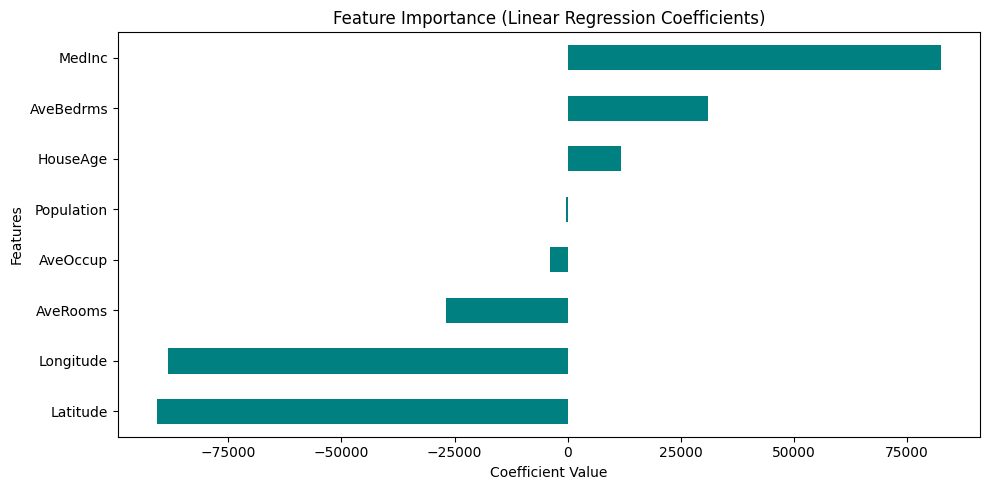

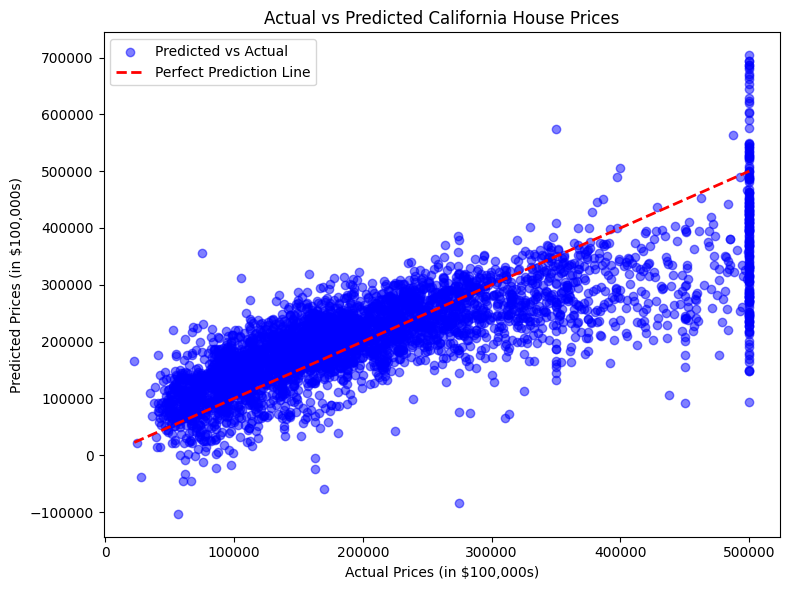


Predicted Median House Value for sample input: $37,728,631,031.59


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# 1. Import Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# 2. Load the California Housing Dataset
# The dataset contains 8 numerical features and 1 target variable (MedHouseVal)
try:
    housing_data = fetch_california_housing(as_frame=True, n_retries=10) # Added n_retries to handle transient download issues
    data = housing_data.frame
except Exception as e:
    print(f"Could not fetch California housing data online: {e}. Loading from local sample_data.")
    # Load from local sample_data if online fetch fails
    train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
    test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')
    # Combine train and test data to mimic the original fetch_california_housing behavior
    data = pd.concat([train_df, test_df], ignore_index=True)

    # Rename and create columns to match the `fetch_california_housing` output
    data = data.rename(columns={
        'longitude': 'Longitude',
        'latitude': 'Latitude',
        'housing_median_age': 'HouseAge',
        'total_rooms': 'TotalRooms',
        'total_bedrooms': 'TotalBedrooms',
        'population': 'Population',
        'households': 'Households',
        'median_income': 'MedInc',
        'median_house_value': 'MedHouseVal'
    })

    # Calculate derived features as in the sklearn dataset
    # Avoid division by zero by handling cases where 'Households' might be zero
    data['AveRooms'] = data['TotalRooms'] / data['Households'].replace(0, np.nan)
    data['AveBedrms'] = data['TotalBedrooms'] / data['Households'].replace(0, np.nan)
    data['AveOccup'] = data['Population'] / data['Households'].replace(0, np.nan)

    # Drop the original total and household columns
    data = data.drop(columns=['TotalRooms', 'TotalBedrooms', 'Households'])

    # Ensure the order of columns matches the expected order of features from sklearn
    expected_columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
    data = data[expected_columns]

# Display basic dataset information
print("Dataset Shape:", data.shape)
print("\nFirst 5 rows of the dataset:")
print(data.head())

# 3. Check for Missing Values
print("\nMissing Values:")
print(data.isnull().sum())

# 4. Separate Features (X) and Target Variable (y)
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']

# 5. Split Data into Training and Testing Sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Feature Scaling (Standardization)
# Standardizes features by removing the mean and scaling to unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Initialize and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 8. Make Predictions on the Test Set
y_pred = model.predict(X_test_scaled)

# 9. Evaluate the Model Performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Results ---")
print(f"Model Intercept: {model.intercept_:.4f}")
print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# 10. Visualization: Feature Importance (Model Coefficients)
plt.figure(figsize=(10, 5))
feature_importance = pd.Series(model.coef_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 11. Visualization: Actual vs. Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Prices (in $100,000s)')
plt.ylabel('Predicted Prices (in $100,000s)')
plt.title('Actual vs Predicted California House Prices')
plt.legend()
plt.tight_layout()
plt.show()

# 12. Make a Single Prediction with Custom Sample Input
# Order of features: [MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude]
sample_input = np.array([[8.0, 20.0, 5.0, 1.0, 1000.0, 3.0, 34.0, -118.0]]) # Example: high income, moderate age area

# Remember to scale the sample input using the same scaler fitted on training data
sample_input_scaled = scaler.transform(sample_input)
predicted_value = model.predict(sample_input_scaled)[0]
print(f"\nPredicted Median House Value for sample input: ${predicted_value * 100000:,.2f}")